In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


ORIGINAL COLUMNS:
['datetime', 'global_active_power', 'global_reactive_power', 'voltage', 'global_intensity', 'sub_metering_1', 'sub_metering_2', 'sub_metering_3', 'hour', 'day', 'month', 'weekday', 'is_weekend', 'peak_hour', 'lag_1', 'lag_5', 'lag_60', 'rolling_avg_15', 'rolling_avg_60', 'target_next_active_power']

FIRST 5 ROWS:
              datetime  global_active_power  global_reactive_power  voltage  \
0  2023-01-01 00:00:00                0.647                  0.019   235.92   
1  2023-01-01 00:01:00                0.551                  0.072   238.25   
2  2023-01-01 00:02:00                0.669                  0.020   237.61   
3  2023-01-01 00:03:00                0.800                  0.050   236.23   
4  2023-01-01 00:04:00                0.537                  0.065   237.60   

   global_intensity  sub_metering_1  sub_metering_2  sub_metering_3  hour  \
0              2.74            0.41            0.46            0.95     0   
1              2.31            0.58  

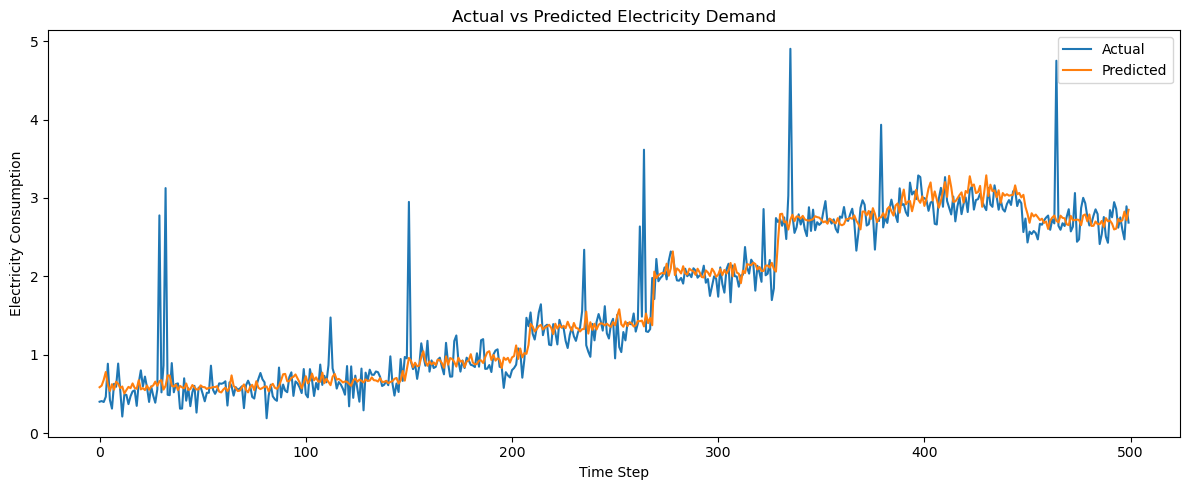



COST ESTIMATION SUMMARY (TEST PERIOD)
Total actual cost    : $84.48
Total predicted cost : $89.15
Mean absolute cost error per reading : $0.00061


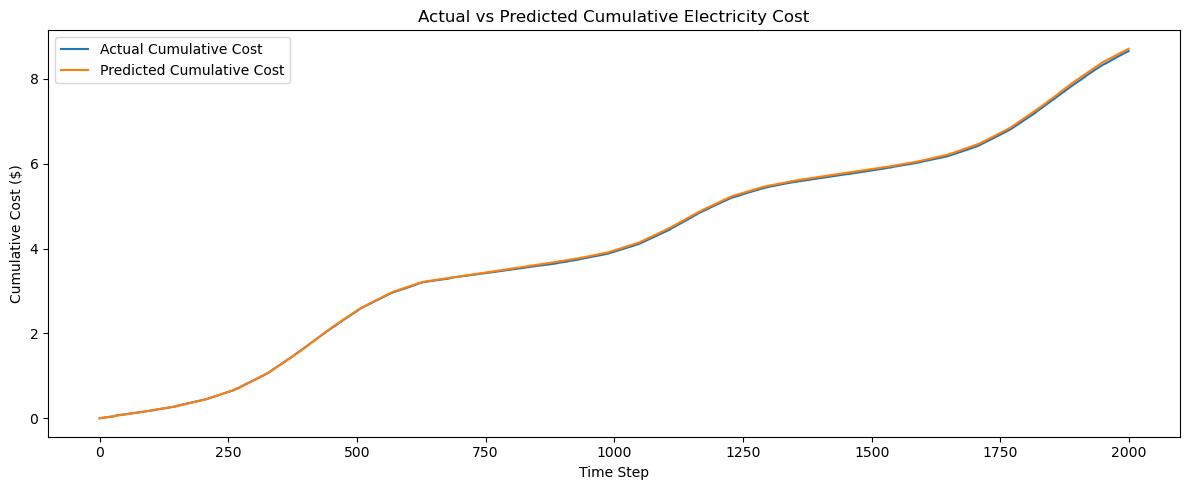


TensorFlow is not installed.
Install using:
pip install tensorflow


MODEL SAVED SUCCESSFULLY
electricity_model_bundle.pkl
✅ Loaded Model: XGBoost
✅ Features: ['global_reactive_power', 'voltage', 'global_intensity', 'sub_metering_1', 'sub_metering_2', 'sub_metering_3', 'hour', 'day', 'month', 'weekday', 'is_weekend', 'is_peak', 'lag_1', 'lag_60', 'rolling_60']


C:\Users\ACER\AppData\Local\Temp\ipykernel_808\4264608305.py:1955: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [2]:
df = pd.read_csv("household_electricity_consumption_100k.csv")

print("\nORIGINAL COLUMNS:")
print(df.columns.tolist())

print("\nFIRST 5 ROWS:")
print(df.head())


# CLEAN COLUMN NAMES

df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("\nCLEANED COLUMNS:")
print(df.columns.tolist())


#  FIND ACTIVE POWER COLUMN


power_names = [
    "Global_active_power",
    "global_active_power",
    "Global_Active_Power",
    "Global_active_power_kW",
    "Global_active_power_kw",
    "Active_power",
    "active_power",
    "Power",
    "power"
]

power_column = None

for col in power_names:
    if col in df.columns:
        power_column = col
        break

if power_column is None:

    for col in df.columns:

        if (
            "active" in col.lower()
            and "power" in col.lower()
        ):
            power_column = col
            break


if power_column is None:

    raise ValueError(
        "❌ Electricity consumption column not found."
    )


df = df.rename(
    columns={
        power_column: "Global_active_power"
    }
)

print(
    "\nActive Power Column:",
    power_column
)


#  CREATE DATETIME


if "Date" in df.columns and "Time" in df.columns:

    df["datetime"] = pd.to_datetime(
        df["Date"].astype(str)
        + " "
        + df["Time"].astype(str),
        dayfirst=True,
        errors="coerce"
    )

    df.drop(
        columns=["Date", "Time"],
        inplace=True
    )


elif "datetime" in df.columns:

    df["datetime"] = pd.to_datetime(
        df["datetime"],
        errors="coerce"
    )


elif "Datetime" in df.columns:

    df["datetime"] = pd.to_datetime(
        df["Datetime"],
        errors="coerce"
    )

    df.drop(
        columns=["Datetime"],
        inplace=True
    )


elif "Date_Time" in df.columns:

    df["datetime"] = pd.to_datetime(
        df["Date_Time"],
        errors="coerce"
    )

    df.drop(
        columns=["Date_Time"],
        inplace=True
    )


else:

    raise ValueError(
        "❌ Date/Time column not found."
    )


#  CLEAN DATETIME


df = df.dropna(
    subset=["datetime"]
)

df = df.sort_values(
    "datetime"
)

df = df.set_index(
    "datetime"
)



# 6. CONVERT NUMERIC COLUMNS

for col in df.columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )



#  HANDLE MISSING VALUES


df = df.interpolate(
    method="time"
)

df = df.ffill()
df = df.bfill()


print("\nCLEANED DATA:")
print(df.head())

print("\nDATA SHAPE:")
print(df.shape)


#  FIND ELECTRICITY COLUMNS


def find_column(possible_names, keyword):

    for name in possible_names:

        if name in df.columns:
            return name

    for col in df.columns:

        if keyword.lower() in col.lower():
            return col

    return None


reactive_col = find_column(
    [
        "Global_reactive_power",
        "global_reactive_power"
    ],
    "reactive"
)


voltage_col = find_column(
    [
        "Voltage",
        "voltage"
    ],
    "voltage"
)


intensity_col = find_column(
    [
        "Global_intensity",
        "global_intensity"
    ],
    "intensity"
)


sub1_col = find_column(
    [
        "Sub_metering_1",
        "sub_metering_1"
    ],
    "sub_metering_1"
)


sub2_col = find_column(
    [
        "Sub_metering_2",
        "sub_metering_2"
    ],
    "sub_metering_2"
)


sub3_col = find_column(
    [
        "Sub_metering_3",
        "sub_metering_3"
    ],
    "sub_metering_3"
)


print("\nDETECTED COLUMNS")

print("Active Power :", "Global_active_power")
print("Reactive     :", reactive_col)
print("Voltage      :", voltage_col)
print("Intensity    :", intensity_col)
print("Sub Meter 1  :", sub1_col)
print("Sub Meter 2  :", sub2_col)
print("Sub Meter 3  :", sub3_col)


#  FEATURE ENGINEERING


target_col = "Global_active_power"


df["hour"] = df.index.hour

df["day"] = df.index.day

df["month"] = df.index.month

df["weekday"] = df.index.dayofweek

df["is_weekend"] = (
    df["weekday"] >= 5
).astype(int)


df["is_peak"] = df["hour"].isin(
    [7, 8, 9, 18, 19, 20, 21]
).astype(int)


# Lag 1

df["lag_1"] = (
    df[target_col].shift(1)
)


# Lag 60

df["lag_60"] = (
    df[target_col].shift(60)
)


# Rolling average

df["rolling_60"] = (
    df[target_col]
    .rolling(60)
    .mean()
)


# Target = next electricity consumption

df["target"] = (
    df[target_col].shift(-1)
)


# 10. BUILD FEATURE LIST


features = []


if reactive_col is not None:
    features.append(reactive_col)


if voltage_col is not None:
    features.append(voltage_col)


if intensity_col is not None:
    features.append(intensity_col)


if sub1_col is not None:
    features.append(sub1_col)


if sub2_col is not None:
    features.append(sub2_col)


if sub3_col is not None:
    features.append(sub3_col)


features += [
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",
    "is_peak",
    "lag_1",
    "lag_60",
    "rolling_60"
]



#  REMOVE MISSING VALUES


df = df.dropna(
    subset=features + ["target"]
)


X = df[features]

y = df["target"]


print("\nFINAL FEATURES:")
for feature in features:
    print("-", feature)


print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)


#  CHRONOLOGICAL TRAIN TEST SPLIT

split = int(
    len(df) * 0.80
)


X_train = X.iloc[:split]

X_test = X.iloc[split:]


y_train = y.iloc[:split]

y_test = y.iloc[split:]


print("\nTRAINING RECORDS:")
print(len(X_train))

print("\nTESTING RECORDS:")
print(len(X_test))


#  STANDARD SCALER


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


#  EVALUATION FUNCTION


def evaluate(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = np.mean(
        np.abs(
            (y_true - y_pred)
            /
            np.maximum(
                np.abs(y_true),
                1e-6
            )
        )
    ) * 100

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, rmse, mape, r2


#  CREATE MODELS

models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        XGBRegressor(
            n_estimators=500,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
}


# 1 TRAIN MODELS

predictions = {}

results = []


for name, model in models.items():

    print("\nTraining:", name)

    model.fit(
        X_train_scaled,
        y_train
    )

    pred = model.predict(
        X_test_scaled
    )

    predictions[name] = pred

    mae, rmse, mape, r2 = evaluate(
        y_test,
        pred
    )

    results.append([
        name,
        mae,
        rmse,
        mape,
        r2
    ])


#  MODEL COMPARISON

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ]
)


results_df = results_df.sort_values(
    "RMSE"
)


print("\n")
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)


#  SELECT BEST MODEL


best_name = (
    results_df.iloc[0]["Model"]
)

best_model = models[best_name]


print("\nBEST MODEL:")
print(best_name)


#  ACTUAL VS PREDICTED


plt.figure(
    figsize=(12, 5)
)


plt.plot(
    y_test.iloc[:500].values,
    label="Actual"
)


plt.plot(
    predictions[best_name][:500],
    label="Predicted"
)


plt.xlabel(
    "Time Step"
)

plt.ylabel(
    "Electricity Consumption"
)

plt.title(
    "Actual vs Predicted Electricity Demand"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
#  ELECTRICITY COST / PRICE ESTIMATION
# ============================================================
#



TARIFF = {
    "peak_rate": 0.32,       # $ per kWh during peak hours
    "off_peak_rate": 0.14,   # $ per kWh during off-peak weekday hours
    "weekend_rate": 0.18,    # $ per kWh on weekends (flat)
    "standing_charge": 0.0,  # optional fixed $ per day (leave 0 to ignore)
    "reading_interval_minutes": 1,  # minutes each row of data represents
}


def get_rate(hour, is_weekend, is_peak, tariff=TARIFF):
    """Return the $/kWh rate that applies for a given time context."""
    if is_weekend:
        return tariff["weekend_rate"]
    if is_peak:
        return tariff["peak_rate"]
    return tariff["off_peak_rate"]


def power_to_cost(power_kw, hour, is_weekend, is_peak, minutes=None, tariff=TARIFF):
    """
    Convert a single power reading (kW) into a $ cost, assuming the
    reading is sustained for `minutes` (defaults to the dataset's
    reading interval).
    """
    if minutes is None:
        minutes = tariff["reading_interval_minutes"]

    rate = get_rate(hour, is_weekend, is_peak, tariff)
    kwh = power_kw * (minutes / 60.0)

    return kwh * rate


def series_to_cost(power_series, hour_series, is_weekend_series, is_peak_series,
                    minutes=None, tariff=TARIFF):
    """Vectorized version of power_to_cost for a whole column of readings."""
    if minutes is None:
        minutes = tariff["reading_interval_minutes"]

    rates = np.where(
        is_weekend_series.astype(bool),
        tariff["weekend_rate"],
        np.where(is_peak_series.astype(bool), tariff["peak_rate"], tariff["off_peak_rate"])
    )

    kwh = power_series * (minutes / 60.0)

    return kwh * rates


# Build a cost comparison table over the test period, using the
# best model's power predictions

df_costs = df.loc[X_test.index, ["hour", "is_weekend", "is_peak"]].copy()

df_costs["actual_power"] = y_test.values
df_costs["predicted_power"] = predictions[best_name]

df_costs["actual_cost"] = series_to_cost(
    df_costs["actual_power"].values,
    df_costs["hour"].values,
    df_costs["is_weekend"].values,
    df_costs["is_peak"].values,
)

df_costs["predicted_cost"] = series_to_cost(
    df_costs["predicted_power"].values,
    df_costs["hour"].values,
    df_costs["is_weekend"].values,
    df_costs["is_peak"].values,
)

total_actual_cost = df_costs["actual_cost"].sum()
total_predicted_cost = df_costs["predicted_cost"].sum()
cost_mae = (df_costs["predicted_cost"] - df_costs["actual_cost"]).abs().mean()

print("\n")
print("=" * 70)
print("COST ESTIMATION SUMMARY (TEST PERIOD)")
print("=" * 70)
print(f"Total actual cost    : ${total_actual_cost:,.2f}")
print(f"Total predicted cost : ${total_predicted_cost:,.2f}")
print(f"Mean absolute cost error per reading : ${cost_mae:.5f}")

# Plot cumulative actual vs predicted cost over time
plt.figure(figsize=(12, 5))

plt.plot(
    df_costs["actual_cost"].cumsum().values[:2000],
    label="Actual Cumulative Cost"
)

plt.plot(
    df_costs["predicted_cost"].cumsum().values[:2000],
    label="Predicted Cumulative Cost"
)

plt.xlabel("Time Step")
plt.ylabel("Cumulative Cost ($)")
plt.title("Actual vs Predicted Cumulative Electricity Cost")
plt.legend()
plt.tight_layout()
plt.show()


#  LSTM


try:

    from tensorflow.keras.models import Sequential

    from tensorflow.keras.layers import (
        LSTM,
        Dense,
        Dropout
    )


    print("\n")
    print("=" * 70)
    print("TRAINING LSTM")
    print("=" * 70)


    values = df[
        target_col
    ].values.reshape(-1, 1)


    mm = MinMaxScaler()


    values_scaled = mm.fit_transform(
        values
    )


    def make_sequences(
        data,
        window=60
    ):

        X_seq = []

        y_seq = []

        for i in range(
            window,
            len(data)
        ):

            X_seq.append(
                data[i-window:i]
            )

            y_seq.append(
                data[i]
            )

        return (
            np.array(X_seq),
            np.array(y_seq)
        )


    X_seq, y_seq = make_sequences(
        values_scaled,
        60
    )


    split_seq = int(
        len(X_seq) * 0.80
    )


    Xtr = X_seq[:split_seq]

    Xte = X_seq[split_seq:]


    ytr = y_seq[:split_seq]

    yte = y_seq[split_seq:]


    lstm_model = Sequential([

        LSTM(
            64,
            return_sequences=True,
            input_shape=(
                Xtr.shape[1],
                Xtr.shape[2]
            )
        ),

        Dropout(0.2),

        LSTM(32),

        Dense(1)

    ])


    lstm_model.compile(
        optimizer="adam",
        loss="mse"
    )


    lstm_model.fit(
        Xtr,
        ytr,
        epochs=10,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )


    lstm_scaled_pred = (
        lstm_model.predict(
            Xte,
            verbose=0
        )
    )


    lstm_pred = (
        mm.inverse_transform(
            lstm_scaled_pred
        ).ravel()
    )


    lstm_actual = (
        mm.inverse_transform(
            yte
        ).ravel()
    )


    mae, rmse, mape, r2 = evaluate(
        lstm_actual,
        lstm_pred
    )


    print("\nLSTM RESULTS")

    print(
        f"MAE  : {mae:.4f}"
    )

    print(
        f"RMSE : {rmse:.4f}"
    )

    print(
        f"MAPE : {mape:.2f}%"
    )

    print(
        f"R2   : {r2:.4f}"
    )


    # Save LSTM

    lstm_model.save(
        "electricity_lstm_model.keras"
    )

    joblib.dump(
        mm,
        "lstm_scaler.pkl"
    )

    print(
        "\nLSTM model saved."
    )


except ImportError:

    print(
        "\nTensorFlow is not installed."
    )

    print(
        "Install using:"
    )

    print(
        "pip install tensorflow"
    )



# SAVE COMPLETE MODEL BUNDLE


model_bundle = {

    "model": best_model,

    "scaler": scaler,

    "features": features,

    "target": target_col,

    "best_model_name": best_name,

    "tariff": TARIFF
}


joblib.dump(
    model_bundle,
    "electricity_model_bundle.pkl"
)


print("\n")
print("=" * 70)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 70)

print(
    "electricity_model_bundle.pkl"
)




# GRADIO DEPLOYMENT


import gradio as gr
import pandas as pd
import numpy as np
import joblib


# ============================================================
#  LOAD MODEL BUNDLE
# ============================================================
#```python
# ============================================================
# ⚡ ATTRACTIVE GRADIO UI
# Household Electricity Demand & Cost Prediction
# ============================================================

import gradio as gr
import pandas as pd
import numpy as np
import joblib


# ============================================================
# LOAD MODEL
# ============================================================

bundle = joblib.load("electricity_model_bundle.pkl")

model = bundle["model"]
scaler = bundle["scaler"]
features = bundle["features"]
model_name = bundle["best_model_name"]
tariff = bundle.get("tariff", TARIFF)

print("✅ Loaded Model:", model_name)
print("✅ Features:", features)


# ============================================================
# RATE CALCULATOR
# ============================================================

def get_rate_ui(hour, is_weekend, is_peak, tariff=tariff):

    if is_weekend:
        return tariff["weekend_rate"]

    if is_peak:
        return tariff["peak_rate"]

    return tariff["off_peak_rate"]


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_electricity(
    reactive_power,
    voltage,
    intensity,
    sub_metering_1,
    sub_metering_2,
    sub_metering_3,
    hour,
    day,
    month,
    lag_1,
    lag_60,
    rolling_60,
    duration_hours
):

    try:

        hour = int(hour)
        day = int(day)
        month = int(month)

        # ----------------------------------------------------
        # DATE CONTEXT
        # ----------------------------------------------------

        date = pd.Timestamp(
            year=2026,
            month=month,
            day=day
        )

        weekday = date.dayofweek

    except Exception:

        return (
            """
            <div class="error-card">
                ⚠️ Invalid date<br>
                <small>Please check the selected day and month.</small>
            </div>
            """,
            None
        )


    # --------------------------------------------------------
    # WEEKEND / PEAK
    # --------------------------------------------------------

    is_weekend = int(weekday >= 5)

    is_peak = int(
        hour in [7, 8, 9, 18, 19, 20, 21]
    )


    # --------------------------------------------------------
    # CREATE INPUT DATA
    # --------------------------------------------------------

    input_dict = {

        "Global_reactive_power": reactive_power,

        "Voltage": voltage,

        "Global_intensity": intensity,

        "Sub_metering_1": sub_metering_1,

        "Sub_metering_2": sub_metering_2,

        "Sub_metering_3": sub_metering_3,

        "hour": hour,

        "day": day,

        "month": month,

        "weekday": weekday,

        "is_weekend": is_weekend,

        "is_peak": is_peak,

        "lag_1": lag_1,

        "lag_60": lag_60,

        "rolling_60": rolling_60
    }


    input_df = pd.DataFrame([input_dict])


    # --------------------------------------------------------
    # MATCH MODEL FEATURES
    # --------------------------------------------------------

    for feature in features:

        if feature not in input_df.columns:

            input_df[feature] = 0


    input_df = input_df[features]


    # --------------------------------------------------------
    # SCALE + PREDICT
    # --------------------------------------------------------

    input_scaled = scaler.transform(input_df)

    prediction = float(
        model.predict(input_scaled)[0]
    )


    # --------------------------------------------------------
    # COST CALCULATION
    # --------------------------------------------------------

    rate = get_rate_ui(
        hour,
        is_weekend,
        is_peak
    )

    duration_hours = float(duration_hours)

    est_kwh = prediction * duration_hours

    est_cost = est_kwh * rate


    # --------------------------------------------------------
    # DEMAND STATUS
    # --------------------------------------------------------

    if prediction < 1.0:

        band = "LOW DEMAND"
        emoji = "🟢"
        status_class = "low"

    elif prediction < 2.5:

        band = "MODERATE DEMAND"
        emoji = "🟡"
        status_class = "moderate"

    else:

        band = "HIGH DEMAND"
        emoji = "🔴"
        status_class = "high"


    # --------------------------------------------------------
    # DAY / PEAK LABEL
    # --------------------------------------------------------

    day_type = (
        "Weekend"
        if is_weekend
        else "Weekday"
    )

    peak_label = (
        "Peak Hours"
        if is_peak
        else "Off-Peak Hours"
    )


 
    # BEAUTIFUL RESULT CARD


    result_html = f"""

    <div class="result-wrapper">

        <div class="status-pill {status_class}">
            {emoji} {band}
        </div>

        <div class="prediction-number">
            {prediction:.3f}
            <span>kW</span>
        </div>

        <div class="prediction-label">
            Predicted Electricity Demand
        </div>


        <div class="info-row">

            <div class="mini-card">
                <span class="mini-icon">📅</span>
                <b>{day_type}</b>
                <small>Day Type</small>
            </div>

            <div class="mini-card">
                <span class="mini-icon">⏰</span>
                <b>{peak_label}</b>
                <small>Time Period</small>
            </div>

            <div class="mini-card">
                <span class="mini-icon">🤖</span>
                <b>{model_name}</b>
                <small>ML Model</small>
            </div>

        </div>


        <div class="cost-section">

            <div class="cost-title">
                💰 Electricity Cost Estimate
            </div>

            <div class="cost-grid">

                <div>
                    <span>Rate</span>
                    <strong>${rate:.3f}/kWh</strong>
                </div>

                <div>
                    <span>Energy</span>
                    <strong>{est_kwh:.3f} kWh</strong>
                </div>

                <div class="cost-total">
                    <span>Estimated Cost</span>
                    <strong>${est_cost:.2f}</strong>
                </div>

            </div>

            <div class="duration-text">
                Estimated for {duration_hours:g} hour(s)
            </div>

        </div>

    </div>

    """


    # --------------------------------------------------------
    # GAUGE DATA
    # --------------------------------------------------------

    gauge_df = pd.DataFrame({

        "Level": ["Predicted Demand"],

        "kW": [prediction]

    })


    return result_html, gauge_df



# CUSTOM CSS

custom_css = """

/* =========================================================
   MAIN PAGE
   ========================================================= */

body {

    background:
        radial-gradient(
            circle at top left,
            #172554 0%,
            #020617 45%,
            #000000 100%
        ) !important;

}


.gradio-container {

    max-width: 1250px !important;

    margin: auto !important;

    font-family:
        Inter,
        -apple-system,
        BlinkMacSystemFont,
        "Segoe UI",
        sans-serif !important;

    background: transparent !important;

    color: #f8fafc !important;

}


/* =========================================================
   HERO HEADER
   ========================================================= */

.hero {

    text-align: center;

    padding: 45px 20px 30px;

}


.hero-icon {

    font-size: 55px;

    margin-bottom: 8px;

    filter:
        drop-shadow(
            0 0 20px
            rgba(34,211,238,0.7)
        );

}


.hero-title {

    font-size: 42px !important;

    font-weight: 800 !important;

    margin: 0 !important;

    background:
        linear-gradient(
            90deg,
            #22d3ee,
            #60a5fa,
            #a78bfa
        );

    -webkit-background-clip: text;

    -webkit-text-fill-color: transparent;

}


.hero-subtitle {

    color: #94a3b8;

    font-size: 16px;

    margin-top: 12px;

}


/* =========================================================
   SECTION HEADERS
   ========================================================= */

.section-title {

    font-size: 18px;

    font-weight: 700;

    color: #e2e8f0;

    margin-bottom: 8px;

}


/* =========================================================
   INPUT PANEL
   ========================================================= */

.input-panel {

    background:
        rgba(15,23,42,0.85) !important;

    border:
        1px solid
        rgba(148,163,184,0.15) !important;

    border-radius: 22px !important;

    padding: 25px !important;

    box-shadow:
        0 20px 50px
        rgba(0,0,0,0.35);

}


/* =========================================================
   OUTPUT PANEL
   ========================================================= */

.output-panel {

    background:
        rgba(15,23,42,0.75) !important;

    border:
        1px solid
        rgba(34,211,238,0.15) !important;

    border-radius: 22px !important;

    padding: 25px !important;

    box-shadow:
        0 20px 50px
        rgba(0,0,0,0.35);

}


/* =========================================================
   INPUT BOXES
   ========================================================= */

input,
textarea {

    background:
        rgba(30,41,59,0.8) !important;

    color: #f8fafc !important;

    border:
        1px solid
        #334155 !important;

    border-radius: 12px !important;

}


input:focus {

    border-color:
        #22d3ee !important;

    box-shadow:
        0 0 0 2px
        rgba(34,211,238,0.15) !important;

}


/* =========================================================
   BUTTON
   ========================================================= */

.predict-btn {

    background:
        linear-gradient(
            90deg,
            #06b6d4,
            #3b82f6,
            #8b5cf6
        ) !important;

    border: none !important;

    border-radius: 14px !important;

    font-size: 17px !important;

    font-weight: 700 !important;

    padding: 15px !important;

    box-shadow:
        0 8px 25px
        rgba(59,130,246,0.35);

    transition:
        all 0.25s ease;

}


.predict-btn:hover {

    transform:
        translateY(-2px);

    box-shadow:
        0 12px 35px
        rgba(34,211,238,0.45);

}


/* =========================================================
   RESULT CARD
   ========================================================= */

.result-wrapper {

    text-align: center;

    padding: 25px;

}


.status-pill {

    display: inline-block;

    padding: 7px 18px;

    border-radius: 999px;

    font-size: 12px;

    font-weight: 800;

    letter-spacing: 0.8px;

}


.status-pill.low {

    background:
        rgba(34,197,94,0.15);

    color: #4ade80;

}


.status-pill.moderate {

    background:
        rgba(234,179,8,0.15);

    color: #facc15;

}


.status-pill.high {

    background:
        rgba(239,68,68,0.15);

    color: #f87171;

}


.prediction-number {

    font-size: 58px;

    line-height: 1;

    font-weight: 900;

    margin-top: 22px;

    background:
        linear-gradient(
            90deg,
            #22d3ee,
            #60a5fa,
            #a78bfa
        );

    -webkit-background-clip: text;

    -webkit-text-fill-color: transparent;

}


.prediction-number span {

    font-size: 22px;

}


.prediction-label {

    color: #94a3b8;

    margin-top: 10px;

    font-size: 14px;

}


/* =========================================================
   MINI CARDS
   ========================================================= */

.info-row {

    display: grid;

    grid-template-columns:
        repeat(3, 1fr);

    gap: 10px;

    margin-top: 25px;

}


.mini-card {

    background:
        rgba(30,41,59,0.65);

    border:
        1px solid
        rgba(148,163,184,0.12);

    border-radius: 14px;

    padding: 15px 8px;

}


.mini-icon {

    display: block;

    font-size: 20px;

    margin-bottom: 7px;

}


.mini-card b {

    display: block;

    font-size: 12px;

    color: #e2e8f0;

}


.mini-card small {

    display: block;

    color: #64748b;

    margin-top: 4px;

    font-size: 10px;

}


/* =========================================================
   COST CARD
   ========================================================= */

.cost-section {

    margin-top: 25px;

    padding: 20px;

    border-radius: 17px;

    background:
        linear-gradient(
            135deg,
            rgba(6,182,212,0.08),
            rgba(99,102,241,0.08)
        );

    border:
        1px solid
        rgba(34,211,238,0.12);

}


.cost-title {

    font-size: 16px;

    font-weight: 700;

    margin-bottom: 18px;

    color: #e2e8f0;

}


.cost-grid {

    display: grid;

    grid-template-columns:
        repeat(3, 1fr);

    gap: 10px;

}


.cost-grid div {

    text-align: left;

}


.cost-grid span {

    display: block;

    color: #64748b;

    font-size: 11px;

    margin-bottom: 5px;

}


.cost-grid strong {

    font-size: 15px;

    color: #cbd5e1;

}


.cost-total strong {

    color: #22d3ee;

    font-size: 19px;

}


.duration-text {

    color: #64748b;

    font-size: 11px;

    margin-top: 15px;

}


/* =========================================================
   ERROR
   ========================================================= */

.error-card {

    padding: 25px;

    border-radius: 16px;

    text-align: center;

    background:
        rgba(127,29,29,0.25);

    border:
        1px solid
        rgba(248,113,113,0.3);

    color: #f87171;

    font-weight: 700;

}


.error-card small {

    display: block;

    margin-top: 8px;

    color: #fca5a5;

}


/* =========================================================
   FOOTER
   ========================================================= */

.dashboard-footer {

    text-align: center;

    color: #64748b;

    font-size: 12px;

    padding: 25px 0;

}


.dashboard-footer span {

    color: #22d3ee;

}


/* =========================================================
   RESPONSIVE
   ========================================================= */

@media (max-width: 700px) {

    .hero-title {

        font-size: 29px !important;

    }

    .prediction-number {

        font-size: 45px;

    }

    .info-row,
    .cost-grid {

        grid-template-columns:
            1fr;

    }

}

"""


# ============================================================
# GRADIO THEME
# ============================================================

theme = gr.themes.Base(

    primary_hue="cyan",

    secondary_hue="blue",

    neutral_hue="slate",

    font=[
        gr.themes.GoogleFont("Inter"),
        "sans-serif"
    ]

).set(

    body_background_fill="#020617",

    body_background_fill_dark="#020617",

    block_background_fill="rgba(15,23,42,0.8)",

    block_border_width="0px",

    button_primary_background_fill=
        "linear-gradient(90deg,#06b6d4,#3b82f6,#8b5cf6)",

    button_primary_background_fill_hover=
        "linear-gradient(90deg,#0891b2,#2563eb,#7c3aed)",

    button_primary_text_color="#ffffff",

    input_background_fill=
        "rgba(30,41,59,0.8)",

    input_border_color="#334155",

    block_radius="18px"

)


# BUILD APPLICATION


with gr.Blocks(

    theme=theme,

    css=custom_css,

    title="⚡ EnergyAI — Electricity Predictor"

) as app:


    # --------------------------------------------------------
    # HERO
    # --------------------------------------------------------

    gr.HTML("""

    <div class="hero">

        <div class="hero-icon">⚡</div>

        <h1 class="hero-title">
            EnergyAI
        </h1>

        <div class="hero-subtitle">
            Household Electricity Demand & Cost Prediction
        </div>

        <div class="hero-subtitle">
            Machine Learning Powered Energy Intelligence
        </div>

    </div>

    """)


   
    # MAIN CONTENT
   

    with gr.Row():


        # ====================================================
        # LEFT PANEL
        # ====================================================

        with gr.Column(
            scale=1,
            elem_classes="input-panel"
        ):

            gr.Markdown(
                "### 🔌 Electrical Measurements",
                elem_classes="section-title"
            )


            with gr.Row():

                reactive_power = gr.Number(
                    label="Reactive Power (kVAR)",
                    value=0.1
                )

                voltage = gr.Number(
                    label="Voltage (V)",
                    value=230
                )


            intensity = gr.Number(
                label="Current Intensity (A)",
                value=4.5
            )


            gr.Markdown(
                "### 🏠 Household Sub-Metering"
            )


            with gr.Row():

                sub_metering_1 = gr.Number(
                    label="Kitchen",
                    value=0
                )

                sub_metering_2 = gr.Number(
                    label="Laundry",
                    value=1
                )

                sub_metering_3 = gr.Number(
                    label="Water Heater / AC",
                    value=17
                )


            gr.Markdown(
                "### 🕒 Time Context"
            )


            hour = gr.Slider(
                minimum=0,
                maximum=23,
                value=18,
                step=1,
                label="Hour of Day"
            )


            with gr.Row():

                day = gr.Slider(
                    minimum=1,
                    maximum=31,
                    value=15,
                    step=1,
                    label="Day"
                )

                month = gr.Slider(
                    minimum=1,
                    maximum=12,
                    value=8,
                    step=1,
                    label="Month"
                )


            gr.Markdown(
                "### 📈 Recent Consumption History"
            )


            with gr.Row():

                lag_1 = gr.Number(
                    label="Lag 1 (kW)",
                    value=1.2
                )

                lag_60 = gr.Number(
                    label="Lag 60 (kW)",
                    value=1.1
                )


            rolling_60 = gr.Number(
                label="60-Step Rolling Average (kW)",
                value=1.15
            )


            gr.Markdown(
                "### 💰 Cost Estimation"
            )


            duration_hours = gr.Slider(
                minimum=0.25,
                maximum=24,
                value=1,
                step=0.25,
                label="Prediction Duration (Hours)"
            )


            predict_btn = gr.Button(
                "⚡ Predict Electricity Demand",
                variant="primary",
                size="lg",
                elem_classes="predict-btn"
            )


        # ====================================================
        # RIGHT PANEL
        # ====================================================

        with gr.Column(
            scale=1,
            elem_classes="output-panel"
        ):

            gr.Markdown(
                "### 🔮 AI Prediction"
            )


            result_display = gr.HTML(

                """
                <div class="result-wrapper">

                    <div class="status-pill moderate">
                        ⚡ READY
                    </div>

                    <div class="prediction-number">
                        —
                        <span>kW</span>
                    </div>

                    <div class="prediction-label">
                        Enter your household readings
                        and run the prediction.
                    </div>

                </div>
                """

            )


            gr.Markdown(
                "### 📊 Demand Visualization"
            )


            gauge_chart = gr.BarPlot(

                x="Level",

                y="kW",

                y_lim=[0, 5],

                title="Predicted Electricity Load",

                height=280,

                show_label=False

            )


            gr.Markdown(
                f"""
                ### 🤖 Model Information

                **Active Model:** `{model_name}`

                **Prediction Type:** Future Electricity Demand

                **Evaluation:** MAE · RMSE · MAPE · R²

                **Application:** Household Energy Management
                """

            )


  
    # FOOTER
   

    gr.HTML("""

    <div class="dashboard-footer">

        ⚡ <span>EnergyAI</span>

        · Built with Python, Scikit-Learn, XGBoost & Gradio

        · Smart Energy Prediction System

    </div>

    """)



    # BUTTON EVENT
  

    predict_btn.click(

        fn=predict_electricity,

        inputs=[

            reactive_power,

            voltage,

            intensity,

            sub_metering_1,

            sub_metering_2,

            sub_metering_3,

            hour,

            day,

            month,

            lag_1,

            lag_60,

            rolling_60,

            duration_hours

        ],

        outputs=[

            result_display,

            gauge_chart

        ]

    )


# ============================================================
# LAUNCH
# ============================================================

if __name__ == "__main__":

    app.launch()

